In [1]:
import pathlib
import sys
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from seagliderOG1 import convertOG1, writers
from tqdm import tqdm
import xarray as xr
import importlib
import numpy as np

script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
sys.path.append(str(parent_dir))
from dissipationSML import reading, plotting, tools,interactive

/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/seagliderOG1/tools.py:483: SyntaxWarning: invalid escape sequence '\d'
  fill_val = 2 ** (int(re.findall("\d+", str(new_dtype))[0]) - 1) - 1


In [146]:
importlib.reload(reading)
importlib.reload(plotting)
importlib.reload(tools)
importlib.reload(interactive)

<module 'dissipationSML.interactive' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/interactive.py'>

## 1. Chose the glider and the mission

In [ ]:
# Example usage
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
selected_glider = interactive.interactive_glider_selection(yaml_path)

Dropdown(description='Select Glider:', index=6, options=('005', '012', '014', '016', '101', '102', '103', '104…

Dropdown(description='Select Mission:', options=('02/07 (dives: 679)', '11/07 (dives: 524)', '02/09 (dives: 48…

Button(description='Confirm Selection', style=ButtonStyle())

Selected Path: https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/103/20070218/


In [202]:
### From the chosen glider mission, the important variables are taken. The destination folder is also selected here.
### The mission path gives the exact path to the dedicated mission of the chosen glider. It will be used later to save and load the concatenated/converted data
data_path = selected_glider['path']
end_profile = selected_glider['dives']
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"
mission_path = destination_folder + '/' + selected_glider['glider'] + '/' + selected_glider['mission']

### 1.1 Load the data into a list of .nc files and then convert into OG1 format which is also concatenating the data. 
### The data is saved at the mission path 

In [184]:
### All datasets from the glider mission are downloaded and then loaded as .nc file into one list
datasets = reading.read_basestation(data_path, destination_path=destination_folder, start_profile=1, end_profile=end_profile)


File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20071113/p1030397_20080120.nc


In [21]:
variables_needed = ['LONGITUDE','LATITUDE','TIME','DEPTH','GLIDER_VERT_VELO_MODEL','THETA','TEMP',
                    'GLIDE_SPEED','SIGTHETA','SIGMA_T','PSAL','PRES','GLIDER_HORZ_VELO_MODEL','DIVE_NUMBER','PROFILE_NUMBER','PSAL_RAW','TEMP_RAW']
### convert the dataset to OG1 format only with the variables needed
ds = reading.convert_with_variables(datasets,variables_needed)
### calculate potential density from raw data and add it to the dataset
ds = tools.add_pot_densities(ds,use_raw=True)
ds = tools.add_pot_densities(ds,use_raw=False)

Converting datasets to OG1 format:  99%|█████████▉| 369/371 [02:20<00:00,  2.65it/s]/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/seagliderOG1/utilities.py:35: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds1 = ds1.assign_coords(longitude=("sg_data_point", [float('nan')] * ds1.dims['sg_data_point']))
/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/seagliderOG1/utilities.py:38: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds1 = ds1.assign_coords(latitude=("sg_data_point", [float('nan')] * ds1.dims['sg_data_point']))


p1040370_20071112: No coord longitude - adding as NaNs to length of sg_data_point
p1040370_20071112: No coord latitude - adding as NaNs to length of sg_data_point
p1040370_20071112: !!! No variable ctd_time - returning an empty dataset


Converting datasets to OG1 format: 100%|██████████| 371/371 [02:20<00:00,  2.64it/s]


In [22]:
### save the OG1 dataset at the destination folder
writers.save_dataset(ds, mission_path + '/all_data_OG1.nc')

True

### 2. Load the dataset and do some plotting

In [154]:
ds = xr.open_dataset(mission_path + '/all_data_OG1.nc')

In [150]:
ds

<xarray.Dataset> Size: 43MB
Dimensions:                 (N_MEASUREMENTS: 355737)
Coordinates:
    LONGITUDE               (N_MEASUREMENTS) float64 3MB ...
    LATITUDE                (N_MEASUREMENTS) float64 3MB ...
    TIME                    (N_MEASUREMENTS) datetime64[ns] 3MB ...
    DEPTH                   (N_MEASUREMENTS) float64 3MB ...
Dimensions without coordinates: N_MEASUREMENTS
Data variables: (12/17)
    GLIDER_VERT_VELO_MODEL  (N_MEASUREMENTS) float32 1MB ...
    THETA                   (N_MEASUREMENTS) float32 1MB ...
    TEMP                    (N_MEASUREMENTS) float32 1MB ...
    GLIDE_SPEED             (N_MEASUREMENTS) float32 1MB ...
    SIGTHETA                (N_MEASUREMENTS) float32 1MB ...
    SIGMA_T                 (N_MEASUREMENTS) float32 1MB ...
    ...                      ...
    PSAL_RAW                (N_MEASUREMENTS) float32 1MB ...
    TEMP_RAW                (N_MEASUREMENTS) float32 1MB ...
    SIGTHETA_RAW            (N_MEASUREMENTS) float64 3MB ...
    SIGMA_T_RAW             (N_MEASUREMENTS) float64 3MB ...
    SIGMA_1_RAW             (N_MEASUREMENTS) float64 3MB ...
    SIGMA_1                 (N_MEASUREMENTS) float64 3MB ...
Attributes: (12/39)
    title:                                      OceanGliders trajectory file
    id:                                         sg103_20070218T145206_delayed
    platform:                                   sub-surface gliders
    platform_vocabulary:                        https://vocab.nerc.ac.uk/coll...
    naming_authority:                           edu.washington.apl
    institution:                                School of Oceanography\nUnive...
    ...                                         ...
    keywords:                                   Water Temperature, Conductivi...
    disclaimer:                                 Data provided AS-IS.
    file_version:                               2.71
    keywords_vocabulary:                        NASA/GCMD Earth Science Keywo...
    acknowledgment:                             National Science Foundation, ...
    license:                                    These data may be redistribut...

### 2.1 Plot the glider track and minimum/mximum depth

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


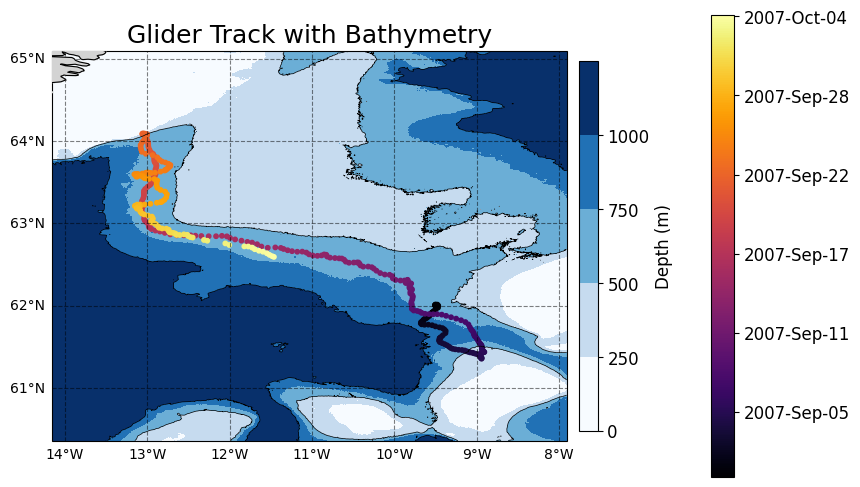

In [103]:
importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds)
display(fig)
### save the figure
#fig.savefig(mission_path + '/glider_track.png', dpi=300)
del fig, ax

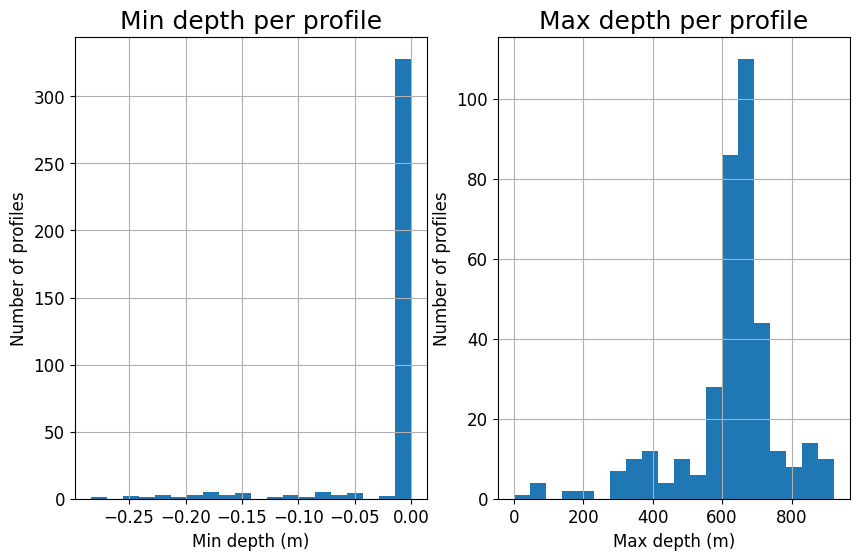

In [104]:
fig, ax = plotting.plot_min_max_depth(ds)
display(fig)
#fig.savefig(mission_path + '/min_max_histogram.png', dpi=300)
del fig, ax


### 2.2 Plot profiles interactively with the possibility of binning

In [162]:
profile_slider = widgets.SelectionSlider(options=np.unique(ds.PROFILE_NUMBER.values).astype(int), description='Profile number:', continuous_update=False)
raw_button = widgets.Checkbox(value=False, description='Raw data')
binning_slider = widgets.IntSlider(value=2, min=1, max=20, description='Binning (m):')
agg_button = widgets.ToggleButtons(options=['mean', 'median'],description='Aggregation:',disabled=False,button_style='')
#var_dropdown = widgets.Dropdown(options=var_options, value=var_options[0], description="Variable:")

In [163]:
interactive.interactive_profile(ds,profile_slider)

Output()

In [209]:
ds_2 = ds.where(ds.PROFILE_NUMBER == 3, drop=True)

In [210]:
ds_2

<xarray.Dataset> Size: 11kB
Dimensions:                 (N_MEASUREMENTS: 92)
Coordinates:
    LONGITUDE               (N_MEASUREMENTS) float64 736B -9.714 ... -9.713
    LATITUDE                (N_MEASUREMENTS) float64 736B 61.21 61.21 ... 61.21
    TIME                    (N_MEASUREMENTS) datetime64[ns] 736B 2007-02-18T1...
    DEPTH                   (N_MEASUREMENTS) float64 736B 0.0 0.0 ... 48.04
Dimensions without coordinates: N_MEASUREMENTS
Data variables: (12/17)
    GLIDER_VERT_VELO_MODEL  (N_MEASUREMENTS) float32 368B nan nan ... nan nan
    THETA                   (N_MEASUREMENTS) float32 368B nan nan ... nan nan
    TEMP                    (N_MEASUREMENTS) float32 368B nan nan ... 8.845
    GLIDE_SPEED             (N_MEASUREMENTS) float32 368B nan nan ... nan nan
    SIGTHETA                (N_MEASUREMENTS) float32 368B nan nan ... nan nan
    SIGMA_T                 (N_MEASUREMENTS) float32 368B nan nan ... nan nan
    ...                      ...
    PSAL_RAW                (N_MEASUREMENTS) float32 368B nan nan ... 35.3 35.3
    TEMP_RAW                (N_MEASUREMENTS) float32 368B nan nan ... 8.845
    SIGTHETA_RAW            (N_MEASUREMENTS) float64 736B nan nan ... 1.027e+03
    SIGMA_T_RAW             (N_MEASUREMENTS) float64 736B nan nan ... 27.38
    SIGMA_1_RAW             (N_MEASUREMENTS) float64 736B nan nan ... 31.86
    SIGMA_1                 (N_MEASUREMENTS) float64 736B nan nan ... nan nan
Attributes: (12/39)
    title:                                      OceanGliders trajectory file
    id:                                         sg103_20070218T145206_delayed
    platform:                                   sub-surface gliders
    platform_vocabulary:                        https://vocab.nerc.ac.uk/coll...
    naming_authority:                           edu.washington.apl
    institution:                                School of Oceanography\nUnive...
    ...                                         ...
    keywords:                                   Water Temperature, Conductivi...
    disclaimer:                                 Data provided AS-IS.
    file_version:                               2.71
    keywords_vocabulary:                        NASA/GCMD Earth Science Keywo...
    acknowledgment:                             National Science Foundation, ...
    license:                                    These data may be redistribut...

In [211]:
importlib.reload(tools)
df = tools.bin_profile(ds_2, vars = ['TEMP','SIGMA_1'], binning=2)

Binning profile 3.0 with binning 2 m


In [191]:
df

,TEMP,SIGMA_1,DEPTH,PROFILE_NUMBER


In [11]:
interactive.interactive_resolution_hist(ds, profile_slider)

interactive(children=(SelectionSlider(continuous_update=False, description='Profile number:', index=770, optio…

In [213]:
importlib.reload(tools)
mld_CR = tools.compute_mld(ds,variable='SIGMA_1',method='CR',threshold= -3,use_bins=True,binning=5)
mld_treshold = tools.compute_mld(ds,variable='SIGMA_T',method='threshold',threshold = 0.03,ref_depth=10,use_bins=True,binning=5)

Binning profile 1.0 with binning 5 m
Binning profile 2.0 with binning 5 m
Binning profile 3.0 with binning 5 m
Binning profile 4.0 with binning 5 m
Binning profile 5.0 with binning 5 m
Binning profile 6.0 with binning 5 m
Binning profile 7.0 with binning 5 m
Binning profile 8.0 with binning 5 m
Binning profile 9.0 with binning 5 m
Binning profile 10.0 with binning 5 m
Binning profile 11.0 with binning 5 m
Binning profile 12.0 with binning 5 m
Binning profile 13.0 with binning 5 m
Binning profile 14.0 with binning 5 m
Binning profile 15.0 with binning 5 m
Binning profile 16.0 with binning 5 m
Binning profile 17.0 with binning 5 m
Binning profile 18.0 with binning 5 m
Binning profile 19.0 with binning 5 m
Binning profile 20.0 with binning 5 m
Binning profile 21.0 with binning 5 m
Binning profile 22.0 with binning 5 m
Binning profile 23.0 with binning 5 m
Binning profile 24.0 with binning 5 m
Binning profile 25.0 with binning 5 m
Binning profile 26.0 with binning 5 m
Binning profile 27.0 

In [214]:
mld_CR

,PROFILE_NUMBER,MLD,TIME
0,1.0,NaN,2007-02-18 14:55:23.552238592
1,2.0,NaN,2007-02-18 15:06:25.796875008
2,3.0,NaN,2007-02-18 16:15:41.206521856
3,4.0,NaN,2007-02-18 16:26:12.837209344
4,5.0,NaN,2007-02-18 17:24:54.084070912
...,...,...,...
1353,1354.0,65.342634,2007-06-09 02:29:02.327043840
1354,1355.0,69.103260,2007-06-09 03:38:25.128205056
1355,1356.0,63.942339,2007-06-09 04:39:10.749999872
1356,1357.0,79.192979,2007-06-09 05:50:31.268292608


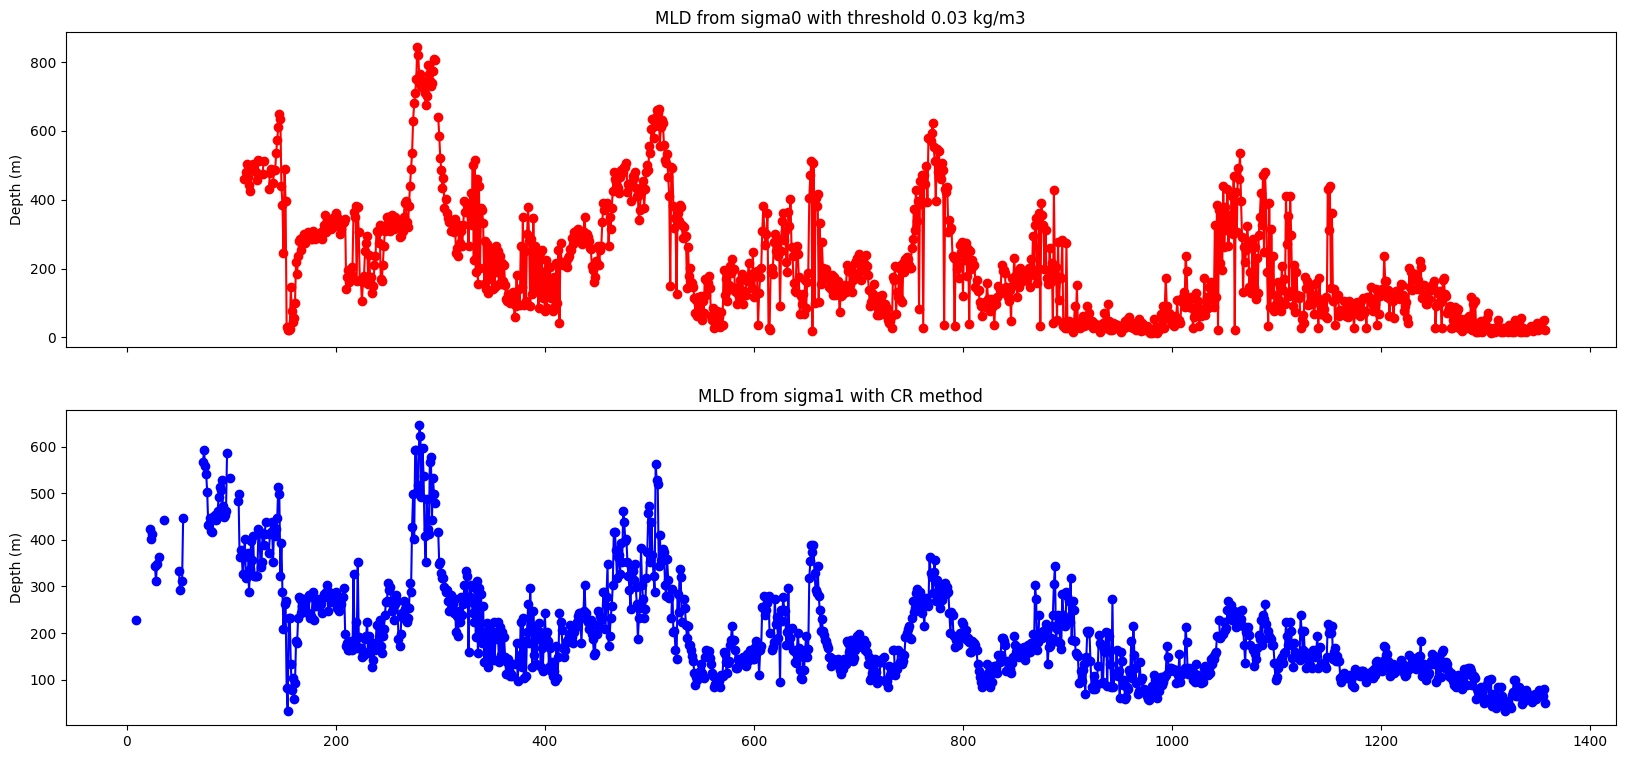

In [215]:
### plot three MLD profiles
fig, ax = plt.subplots(2, 1, figsize=(20, 9), sharex=True)
mld_treshold['MLD'].plot(ax=ax[0], marker='o', color='red', label='MLD from SIGTHETA with threshold 0.03 kg/m3') 
mld_CR['MLD'].plot(ax=ax[1], marker='o', color='blue', label='MLD from SIGMA1 with CR method')
ax[0].set_title('MLD from sigma0 with threshold 0.03 kg/m3')
ax[1].set_title('MLD from sigma1 with CR method')
ax[0].set_ylabel('Depth (m)')
ax[1].set_ylabel('Depth (m)')

plt.show()

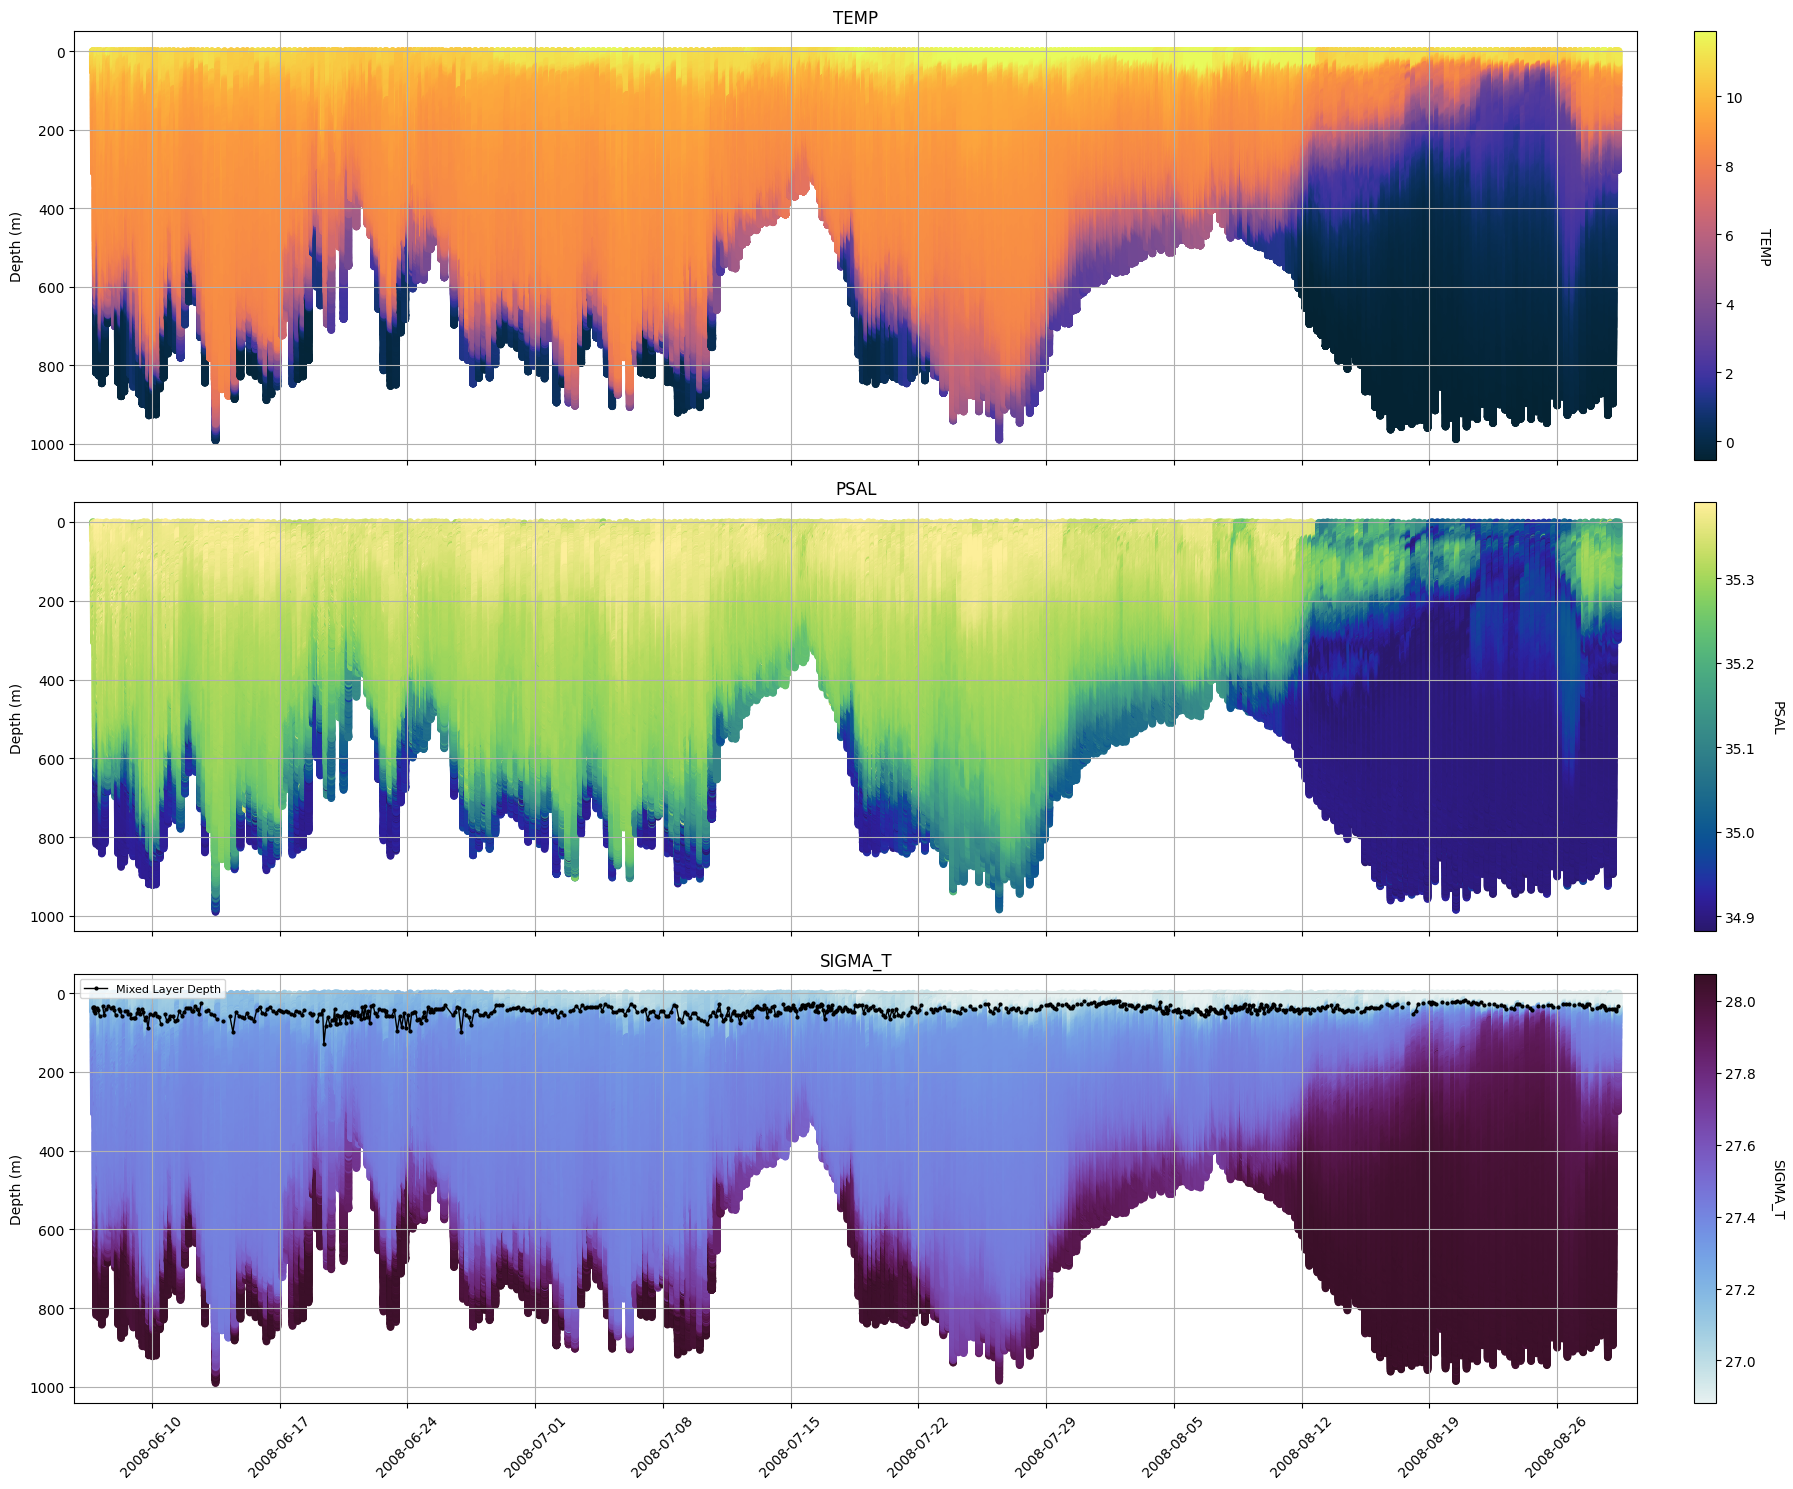

(<Figure size 2000x1500 with 6 Axes>,
 array([<Axes: title={'center': 'TEMP'}, ylabel='Depth (m)'>,
        <Axes: title={'center': 'PSAL'}, ylabel='Depth (m)'>,
        <Axes: title={'center': 'SIGMA_T'}, ylabel='Depth (m)'>],
       dtype=object))

In [306]:
importlib.reload(plotting)
plotting.plot_section(ds, ['TEMP','PSAL','SIGMA_T'], add_MLD=mld_CR)#,start_date='2008-07-01' ,end_date='2008-07-31')

In [84]:
### load the yaml file with yaml_path defined before
import yaml
# Load YAML from a file
with open(yaml_path, 'r') as file:
    config = yaml.safe_load(file)

In [285]:
import xarray as xr
from tqdm import tqdm
importlib.reload(tools)

mld_ds_list = []

for glider in tqdm(config['gliders'], desc="Processing gliders"):
    glider_name = glider['name']
    
    for mission in glider['missions']:
        print(f"Processing glidermission: {mission['folder']}")
        folder = mission.get('folder')
        if folder == 'no folder':
            continue

        file_path = f"{destination_folder}/{folder}/all_data_OG1.nc"
        ds = xr.open_dataset(file_path)

        mld= tools.compute_mld(ds,variable='SIGMA_1',method='CR',threshold= -3,use_bins=True,binning=8)
        #mld = tools.compute_mld(ds,variable='SIGMA_T',method='threshold',threshold = 0.03,ref_depth=10,use_bins=True,binning=10)

        # Add metadata
        mld['MISSION'] = folder.split('/')[-1]
        mld['GLIDER'] = glider_name

        # Set TIME as index and convert to xarray.Dataset
        mld.set_index('TIME', inplace=True)
        mld_ds = xr.Dataset.from_dataframe(mld)

        mld_ds_list.append(mld_ds)

# Concatenate all MLD datasets along TIME dimension
mld_ds = xr.concat(mld_ds_list, dim='TIME')
mld_ds = mld_ds.sortby('TIME')
### somehow some time stamps are from 1970
mld_ds = mld_ds.sel(TIME=slice('2006-01-01', '2009-12-31'))


Processing gliders:   0%|          | 0/9 [00:00<?, ?it/s]

Processing glidermission: 005/20080606


Processing gliders:   0%|          | 0/9 [00:02<?, ?it/s]


KeyboardInterrupt: 

In [286]:
mld_rolling = mld_ds.resample(TIME='12H').mean(dim='TIME')

/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


In [297]:
mld_ds

<xarray.Dataset> Size: 628kB
Dimensions:         (TIME: 15698)
Coordinates:
  * TIME            (TIME) datetime64[ns] 126kB 2006-11-12T10:10:23.138461696...
Data variables:
    PROFILE_NUMBER  (TIME) float64 126kB 1.0 2.0 1.0 2.0 ... 926.0 927.0 928.0
    MLD             (TIME) float64 126kB nan nan nan nan ... 124.3 124.9 140.5
    MISSION         (TIME) object 126kB '20061112' '20061112' ... '20090829'
    GLIDER          (TIME) object 126kB '016' '016' '101' ... '005' '005' '005'

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_22376/3401638792.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_missions))


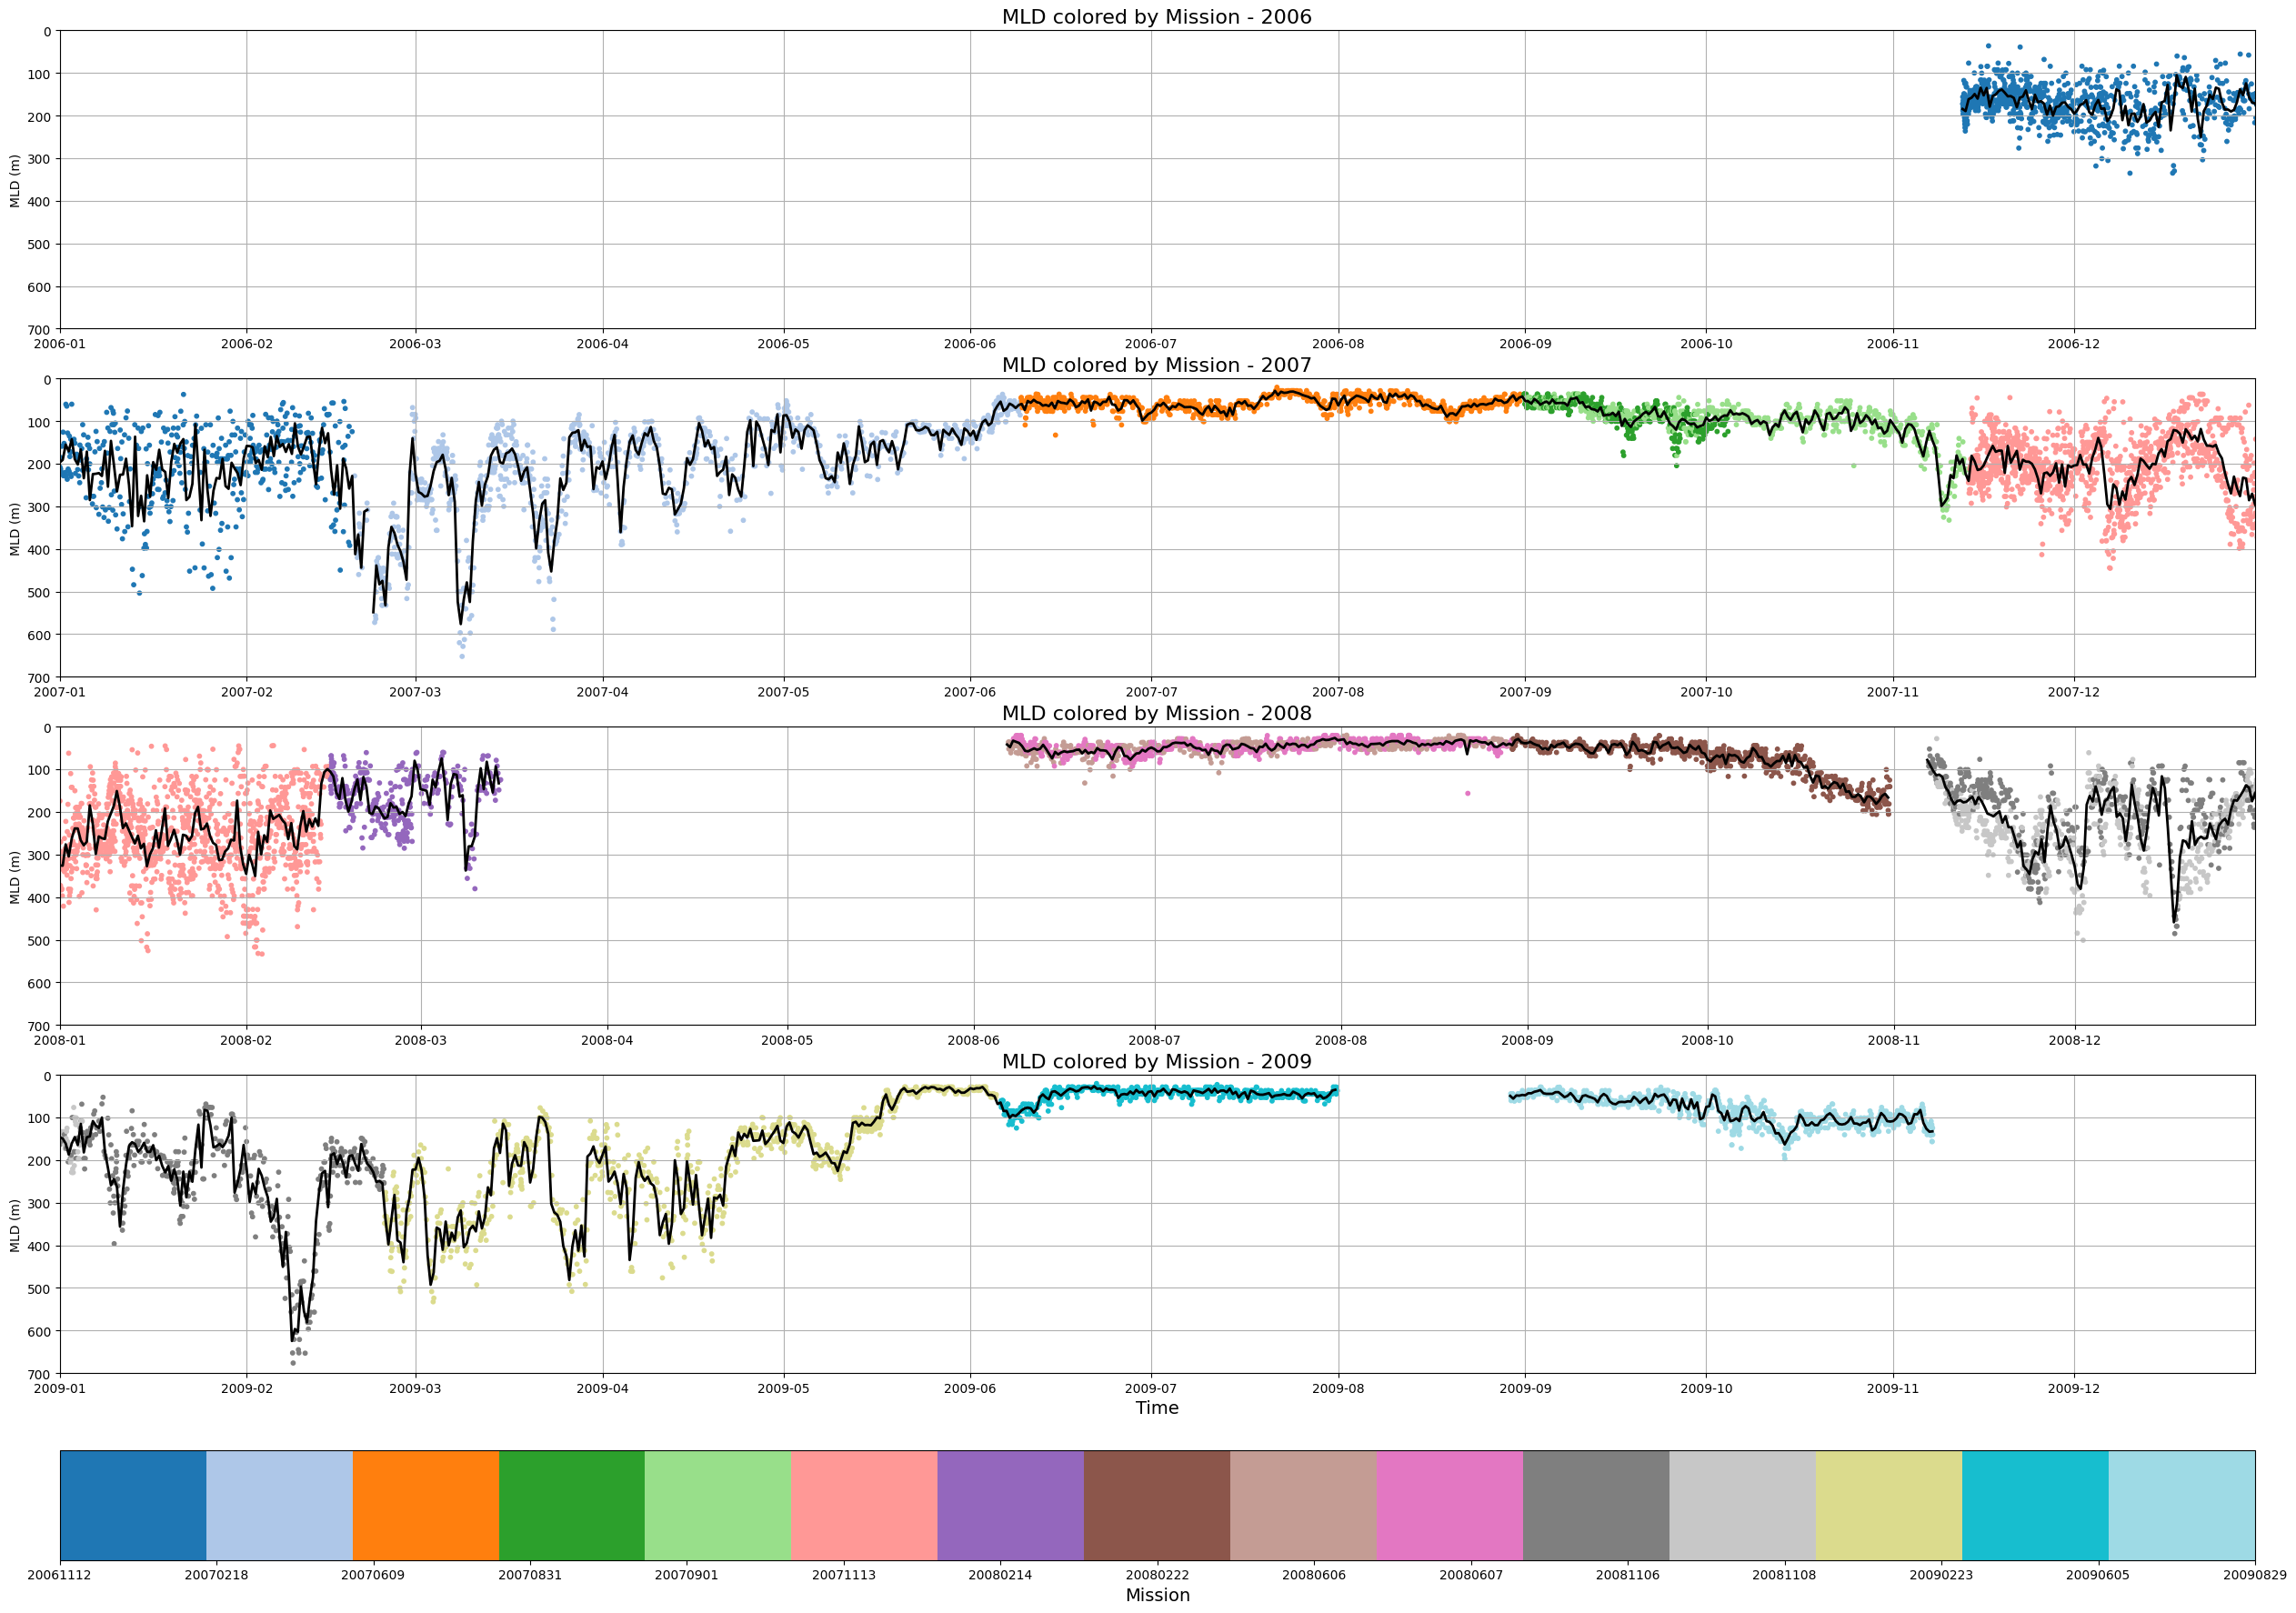

In [300]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# Assume your dataset is called 'mld_ds'

fig, axes = plt.subplots(4, 1, figsize=(25, 18), sharex=False, sharey=True)
years = [2006, 2007, 2008, 2009]

# Map missions to integers for colorbar
unique_missions = np.unique(mld_ds['MISSION'].values)
mission_to_int = {mission: i for i, mission in enumerate(unique_missions)}

# Convert missions to integers
mission_numbers = np.array([mission_to_int[mission] for mission in mld_ds['MISSION'].values])

# Set up colormap
cmap = cm.get_cmap('tab20', len(unique_missions))
norm = mcolors.Normalize(vmin=0, vmax=len(unique_missions) - 1)

for i, year in enumerate(years):
    ax = axes[i]
    mld_year = mld_ds.sel(TIME=slice(f'{year}-01-01', f'{year}-12-31'))
    mld_rolling_year = mld_rolling.sel(TIME=slice(f'{year}-01-01', f'{year}-12-31'))

    sc = ax.scatter(mld_year['TIME'].values, mld_year['MLD'].values, 
                    c=[mission_to_int[m] for m in mld_year['MISSION'].values], 
                    cmap=cmap, norm=norm, s=10)
    ax.plot(mld_rolling_year['TIME'].values, mld_rolling_year['MLD'].values,
            color='black', linewidth=2, label='1D Rolling Mean')

    ax.set_xlim(np.datetime64(f'{year}-01-01'), np.datetime64(f'{year}-12-31'))
    ax.set_ylim(0, 700)
    ax.invert_yaxis()
    ax.set_ylabel('MLD (m)')
    ax.set_title(f'MLD colored by Mission - {year}', fontsize=16)
    ax.grid(True)

axes[-1].set_xlabel('Time', fontsize=14)

# Tight layout BEFORE adding colorbar, rect : tuple (left, bottom, right, top)
fig.tight_layout(rect=[0, 0, 1, 1])  # leave space at bottom for colorbar

# Add one shared colorbar underneath
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), orientation='horizontal', 
                    fraction=0.08, pad=0.05)
cbar.set_ticks(np.arange(len(unique_missions)))
cbar.set_ticklabels(unique_missions)
cbar.set_label('Mission', fontsize=14)

plt.show()


### 2.3 Plot the MLD, depending on the settings that were chosen and add it in the next step to the dataset

In [13]:
# Create sliders for longitude and latitude
default_coords = [[-14.0, 63.5], # First corner
                  [-13, 64.5], # Second corner
                  [-7.5, 62], # Third corner
                  [-9, 61]] # Fourth corner
# Create the interactive selector
get_region = plotting.interactive_region_selector(default_coords)

Button(description='Confirm Selection', style=ButtonStyle())

Output()

Region confirmed!


In [14]:
### get the coordinates of the region and create a new dataset with values only from this region
region = get_region()
ds_region = tools.cut_region(ds, region)

In [15]:
importlib.reload(interactive)
bad_profiles = interactive.interactive_bad_profile_checking(ds_region)

In [48]:
### cutting out profile numbers that are not needed
bad_profiles = np.array(bad_profiles)
ds = ds_region.isel(N_MEASUREMENTS=~np.isin(ds_region.PROFILE_NUMBER.values, bad_profiles))

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


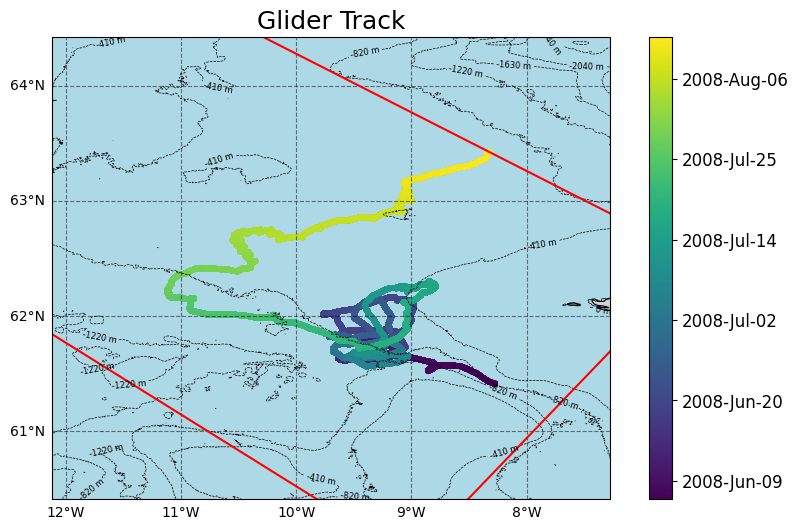

In [20]:
importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds_region)
region.plot(ax=ax, add_label=False, line_kws={'color': 'red'})
display(fig)
#fig.savefig(mission_path + '/glider_track_region.png', dpi=300)
del fig, ax

In [ ]:
### save the dataset with MLD
#writers.save_dataset(ds, mission_path + '/all_data_OG1_with_MLD.nc')